In [32]:
import numpy as np
import networkx as nx

from itertools import combinations
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import PauliEvolutionGate, CXGate, QAOAAnsatz

from qiskit_aer import AerSimulator
from qiskit_aer.backends.backendconfiguration import AerBackendConfiguration

from qopt_best_practices.sat_mapping import SATMapper
from qiskit_qaoa.utils.sat_mapper import HigherOrderSatMapper

from qiskit.quantum_info import SparsePauliOp


from qiskit.transpiler import PassManager
from qiskit.transpiler.passes import HighLevelSynthesis, InverseCancellation
from qopt_best_practices.transpilation.swap_cancellation_pass import SwapToFinalMapping


from qiskit_qaoa.utils.transpiler_passes import ExtendedSwapStrategy, CommutingGateRouter, FindCommutingPauliEvolutionsMulti, DecomposePauliZEvolution

In [36]:
extended_swap_strat = ExtendedSwapStrategy.from_heavy_hex(2, 2)
num_physical_qubits = extended_swap_strat._num_vertices
num_physical_qubits

35

In [37]:
coupling_map_edge = list(extended_swap_strat._coupling_map)
physical_qubits = list(extended_swap_strat._coupling_map.physical_qubits)
dual_coupling_map = nx.Graph()

for qubit in physical_qubits:
    edges = [edge for edge in coupling_map_edge if edge[0]==qubit]
    for edge1, edge2 in combinations(edges, 2):
        dual_coupling_map.add_edge(tuple(sorted(edge1)), tuple(sorted(edge2)))



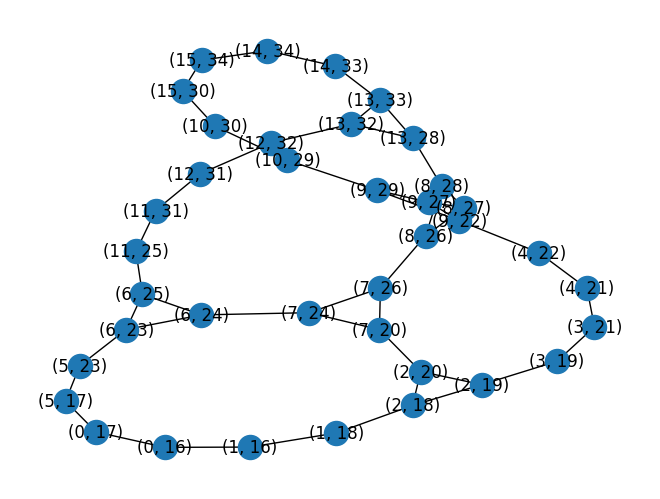

In [43]:
pos = nx.spring_layout(dual_coupling_map)
nx.draw(dual_coupling_map, pos=pos, with_labels=True)

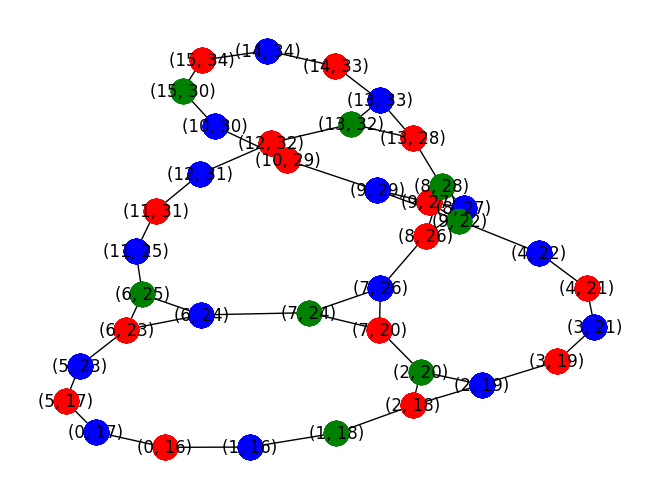

In [52]:
# colour = nx.equitable_color(dual_coupling_map, 3)
colour = nx.greedy_color(dual_coupling_map, interchange=True)

colours = ['red', 'blue', 'green', 'black']
nx.draw(dual_coupling_map, pos=pos, with_labels=True)
for val in colour.values():
    nx.draw_networkx_nodes(dual_coupling_map, pos, nodelist=[x for x in colour.keys() if colour[x] == val], node_color=colours[val])


In [53]:
colour

{(0, 16): 0,
 (0, 17): 1,
 (1, 16): 1,
 (1, 18): 2,
 (2, 18): 0,
 (2, 19): 1,
 (2, 20): 2,
 (3, 19): 0,
 (3, 21): 1,
 (4, 21): 0,
 (4, 22): 1,
 (5, 23): 1,
 (5, 17): 0,
 (6, 23): 0,
 (6, 24): 1,
 (6, 25): 2,
 (7, 24): 2,
 (7, 26): 1,
 (7, 20): 0,
 (8, 26): 0,
 (8, 27): 1,
 (8, 28): 2,
 (9, 27): 0,
 (9, 29): 1,
 (9, 22): 2,
 (10, 29): 0,
 (10, 30): 1,
 (11, 31): 0,
 (11, 25): 1,
 (12, 31): 1,
 (12, 32): 0,
 (13, 32): 2,
 (13, 33): 1,
 (13, 28): 0,
 (14, 33): 0,
 (14, 34): 1,
 (15, 34): 0,
 (15, 30): 2}

In [39]:
len(extended_swap_strat)

100

In [4]:
n = 3
T = 3
num_qubits = n*T

In [5]:
rng = np.random.default_rng(seed=1)
doubles = rng.choice(num_qubits, (20, 2))
quads = rng.choice(num_qubits, (2, 4), replace=False)
coeffs = rng.random(22)

In [6]:
def choice_to_pauli(choice: list[int], size: int) -> str:
    pauli = ['I'] * size
    for x in choice:
        pauli[size - x - 1] = 'Z'
    return ''.join(pauli)

In [7]:
hamiltonian = SparsePauliOp([choice_to_pauli(c, num_qubits) for c in doubles] + [choice_to_pauli(c, num_qubits) for c in quads], coeffs=coeffs)
hamiltonian = hamiltonian.simplify()
hamiltonian = hamiltonian.sort(weight=True)


In [8]:
def hamiltonian_to_doubles_graph(hamiltonian: SparsePauliOp) -> nx.Graph:
    edges = []
    weights = []
    for t in hamiltonian:
        if np.sum(t.paulis[0].z) == 2:
            edge = np.nonzero(t.paulis[0].z)[0]
            edges.append(edge)
            weights.append(t.coeffs[0])
            
    program_graph = nx.Graph()
    for i in range(hamiltonian.num_qubits):
        program_graph.add_node(i)
    for idx in range(len(weights)):
        program_graph.add_edge(edges[idx][0],edges[idx][1],weight=weights[idx])
    return program_graph


In [8]:
def hamiltonian_to_interactions(hamiltonian: SparsePauliOp) -> list[tuple]:
    interactions = []
    for t in hamiltonian:
        if np.sum(t.paulis[0].z) < 1 or np.sum(t.paulis[0].z) > 5:
            continue
        if np.sum(t.paulis[0].z) == 2:
            edge = np.nonzero(t.paulis[0].z)[0]
            interactions.append(edge)
        if np.sum(t.paulis[0].z) == 4:
            edge = np.nonzero(t.paulis[0].z)[0]
            interactions.append(edge)
    return interactions

In [9]:
def print_circuit_info(qc, circuit_name):
    print(f'{circuit_name} has {qc.count_ops().get("cz", 0) + qc.count_ops().get("rzz", 0) + qc.count_ops().get("cx", 0)} 2Q gates \
    and {qc.depth(lambda instr: len(instr.qubits) > 1)} 2Q depth')

In [10]:
basis_gates=["sx", "x", "rz", "rzz", "cz", "id"]
config = AerSimulator._DEFAULT_CONFIGURATION
config["n_qubits"] = num_physical_qubits
config["basis_gates"] = basis_gates
config = AerBackendConfiguration.from_dict(config)
backend = AerSimulator(configuration=config, coupling_map=extended_swap_strat._coupling_map)

In [11]:
backend._basis_gates()

['cz', 'id', 'rz', 'rzz', 'sx', 'x']

In [12]:
pm = PassManager(
    [
        HighLevelSynthesis(basis_gates=["PauliEvolution"]), # Not needed if set up circuit as PauliEvolutionGate
        FindCommutingPauliEvolutionsMulti(), 
        CommutingGateRouter(
            extended_swap_strat,
        ),
        SwapToFinalMapping(),
        HighLevelSynthesis(basis_gates=["sx", "x", "rz", "rzz", "cx", "id"]),
        InverseCancellation(gates_to_cancel=[CXGate()]),
    ]
)

In [ ]:
program_graph = hamiltonian_to_doubles_graph(hamiltonian)


In [ ]:
sat_results = SATMapper(timeout=60).find_initial_mappings(
    program_graph, extended_swap_strat, 0, len(extended_swap_strat)
)
solutions = [k for k, v in sat_results.items() if v.satisfiable]


In [ ]:
solutions

In [ ]:
if len(solutions):
    min_k = min(solutions)
    print(f'Min SWAP layers to satisfy doubles: {min_k}')
    edge_map = dict(sat_results[min_k].mapping)
    print(f'Doubles edge map: {edge_map}')

    new_hamiltonian = hamiltonian.apply_layout([edge_map[i] for i in range(num_qubits)], num_physical_qubits)
    
    new_cost_circ = QuantumCircuit(num_physical_qubits)
    new_cost_circ.append(PauliEvolutionGate(new_hamiltonian), range(num_physical_qubits))
    new_tcost = pm.run(new_cost_circ)
    
    print_circuit_info(new_tcost, 'Remapped, commuting gate routed circuit')
    print(new_tcost.count_ops())
    
    backend_new_tcost = transpile(new_tcost, optimization_level=3, backend=backend, basis_gates=basis_gates)
    
    print_circuit_info(backend_new_tcost, 'Remapped, commuting gate routed circuit on backend')
    print(backend_new_tcost.count_ops())

In [ ]:
qaoa_cost_op = QAOAAnsatz(
    hamiltonian,
    mixer_operator=QuantumCircuit(num_qubits),
    initial_state=QuantumCircuit(num_qubits)
)
backend_tqaoa = transpile(qaoa_cost_op, optimization_level=3, backend=backend, basis_gates=basis_gates)

print_circuit_info(backend_tqaoa, 'Default qaoa circuit on backend')
print(backend_tqaoa.count_ops())

In [13]:
program_interactions = hamiltonian_to_interactions(hamiltonian)
nodes = set([node for interaction in program_interactions for node in interaction])

In [14]:
mapper = HigherOrderSatMapper(timeout=5)
results = {}
for num_layers in range(2,3):
    print('--------------------------------------------------')
    sat_results = mapper.hubo_max_sat(
        program_interactions, extended_swap_strat, num_layers
    )
    mapping = sat_results[num_layers][1]
    edge_map = dict(mapping)
    print(f'Cost: {sat_results[num_layers][0]}')
    print(edge_map)

--------------------------------------------------
13:48:14 - qiskit_qaoa.utils.sat_mapper - INFO - Start populating order 4 distance tensor
13:48:14 - qiskit_qaoa.utils.sat_mapper - INFO - Finished populating order 4 distance tensor
13:48:14 - qiskit_qaoa.utils.sat_mapper - INFO - Num layers: 2
13:48:14 - qiskit_qaoa.utils.sat_mapper - INFO - Re-computing distance tensor
13:48:14 - qiskit_qaoa.utils.sat_mapper - INFO - Re-computing distance tensor
13:48:14 - qiskit_qaoa.utils.sat_mapper - INFO - Hard constraints: 6624
13:48:14 - qiskit_qaoa.utils.sat_mapper - INFO - Soft constraints: 86205
Cost: 2
{0: 9, 1: 24, 2: 20, 3: 1, 4: 7, 5: 23, 6: 28, 7: 26, 8: 8}


Why cost 2 but can't do 7 gates?? Error in SAT mapping?

In [15]:
edge_map = {0: 9, 1: 24, 2: 20, 3: 1, 4: 7, 5: 23, 6: 28, 7: 26, 8: 8}
num_layers = 2
results = {}

In [42]:
print(program_interactions[-2:])

print(quads)
[[edge_map[q] for q in quad] for quad in quads]

[array([0, 1, 6, 7]), array([2, 3, 5, 8])]
[[8 3 5 2]
 [1 0 7 6]]


[[8, 1, 23, 20], [24, 9, 26, 28]]

In [16]:
new_hamiltonian = hamiltonian.apply_layout([edge_map[i] for i in range(num_qubits)], num_physical_qubits)
print([np.nonzero(p.paulis.z)[1] for p in hamiltonian[-2:]])
print([np.nonzero(p.paulis.z)[1] for p in new_hamiltonian[-2:]])

[array([0, 1, 6, 7]), array([2, 3, 5, 8])]
[array([ 9, 24, 26, 28]), array([ 1,  8, 20, 23])]


In [26]:
pm = PassManager(
    [
        # HighLevelSynthesis(basis_gates=["PauliEvolution"]), # Not needed if set up circuit as PauliEvolutionGate
        FindCommutingPauliEvolutionsMulti(), 
        CommutingGateRouter(
            extended_swap_strat,
            max_layers=num_layers,
            perform_extra_swaps=False
        ),
        SwapToFinalMapping(),
        DecomposePauliZEvolution(extended_swap_strat._coupling_map),
        HighLevelSynthesis(
            basis_gates=["sx", "x", "rz", "rzz", "cx", "id", "swap"], 
        ),
        InverseCancellation(gates_to_cancel=[CXGate()]),
    ]
)

In [27]:
new_cost_circ = QuantumCircuit(num_physical_qubits)
new_cost_circ.append(PauliEvolutionGate(new_hamiltonian), range(num_physical_qubits))
new_tcost = pm.run(new_cost_circ)

print_circuit_info(new_tcost, 'Remapped, commuting gate routed circuit')
print(new_tcost.count_ops())

backend_new_tcost = transpile(new_tcost, optimization_level=3, backend=backend, basis_gates=basis_gates)

print_circuit_info(backend_new_tcost, 'Remapped, commuting gate routed circuit on backend')
print(backend_new_tcost.count_ops())
results[num_layers] = (new_tcost, backend_new_tcost)
    

13:52:07 - qiskit_qaoa.utils.transpiler_passes - INFO - Max layers needed to apply swap decompose: 2
13:52:07 - qiskit_qaoa.utils.transpiler_passes - INFO - Layer 0. Sub-layers: 4. Max interaction size: 2
13:52:07 - qiskit_qaoa.utils.transpiler_passes - INFO - Layer 1. Sub-layers: 2. Max interaction size: 2
13:52:07 - qiskit_qaoa.utils.transpiler_passes - INFO - Layer 2. Sub-layers: 2. Max interaction size: 4
13:52:07 - qiskit_qaoa.utils.transpiler_passes - INFO - Gates we cannot directly implement: 2
13:52:07 - qiskit_qaoa.utils.transpiler_passes - INFO - [(20, 26), (1, 26)]
13:52:07 - qiskit_qaoa.utils.transpiler_passes - INFO - Not implementing those gates
13:52:07 - qiskit_qaoa.utils.transpiler_passes - INFO - [<Qubit register=(35, "q"), index=0>, <Qubit register=(35, "q"), index=1>, <Qubit register=(35, "q"), index=2>, <Qubit register=(35, "q"), index=3>, <Qubit register=(35, "q"), index=4>, <Qubit register=(35, "q"), index=5>, <Qubit register=(35, "q"), index=6>, <Qubit register=

In [ ]:
[x for x in list(backend.coupling_map) if x[0] == 8] + [x for x in list(backend.coupling_map) if x[0] == 13]

In [ ]:
[x for x in list(backend.coupling_map) if x[0] == 9] + [x for x in list(backend.coupling_map) if x[0] == 22]

In [21]:
results[2][0].draw(fold=-1)

┌────────────────────┐                                                                                                                                                                                                                                                                                
  q_1 -> 1 ─┤ exp(-it Z)(0.5095) ├──────────────────────────────────────────────────────X─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
            └────────────────────┘                                                      │                                                                                                                                                                                                                         
  q_2 -> 2 ──────────────────────────────────X──────────────────────────────────────────┼────────────────X──────────────────────────────────────────────────────────────────────────────────────────■──────────────────────────────────────────────────────────────────────■────────■─────────────────────────────
                                             │                                          │                │                                                                                          │                                                                      │        │                             
  q_6 -> 6 ──────────────────────────────────┼────────────X─────────────────────────────┼────────────────┼───────────────────────────────────────────────────────────────────────■──────────────────┼───X──────────────────────────────────────────────────────────────────┼────────┼─────────────────────────────
                                             │            │                             │                │              ┌─────────────────────┐                                  │                  │   │                 ┌───┐                        ┌───┐               │        │                             
  q_7 -> 7 ──────────────────────────────────┼────────────┼──■──────────────────────────┼──■─────────────┼──■───────────┤ exp(-it Z)(0.16065) ├────X────────────────■────────────┼──────────────────┼───┼──■────────────X─┤ X ├──────■─────────────────┤ X ├───────────────┼────────┼─────────────────────────────
                                             │            │  │                          │  │             │  │           └─────────────────────┘    │                │            │                  │   │  │            │ └─┬─┘┌───┐ │            ┌───┐└─┬─┘               │  ┌───┐ │           ┌───┐             
  q_8 -> 8 ──────────────────────────────────┼────────────┼──┼─────────────■────────────┼──┼─────────────┼──┼─────────────────■─────────────────X──┼──■─────────────┼────────────┼──────────────X───┼───┼──┼────────────┼───┼──┤ X ├─┼────────────┤ X ├──┼───■─────────────┼──┤ X ├─┼───────────┤ X ├─■───────────
           ┌─────────────────────┐           │            │  │             │            │  │             │  │                 │                 │  │  │             │            │              │   │   │  │            │   │  └─┬─┘ │            └─┬─┘  │   │             │  └─┬─┘ │           └─┬─┘ │           
  q_9 -> 9 ┤ exp(-it Z)(0.52859) ├───────────┼────────────┼──┼─────────────┼────────────┼──┼──────────X──┼──┼─────────────────┼─────────────────┼──┼──┼─────────────┼────────────┼──────────────┼───┼───┼──┼────────────┼───┼────┼───┼──────────────┼────┼───┼─────────────┼────┼───┼─────────────┼───┼───────────
           └─────────────────────┘           │            │  │             │            │  │          │  │  │                 │                 │  │  │             │            │              │   │   │  │            │   │    │   │              │    │   │             │    │   │             │   │           
q_18 -> 18 ──────────

In [ ]:
results[4][1].draw(fold=-1)

In [ ]:
sat_results = HigherOrderSatMapper(timeout=5).find_hubo_mappings(
    program_interactions, extended_swap_strat, 0, len(extended_swap_strat)
)
solutions = [k for k, v in sat_results.items() if v.satisfiable]

In [ ]:
solutions

In [ ]:
if len(solutions):
    min_k = min(solutions)
    print(f'Min SWAP layers to satisfy HUBO: {min_k}')
    edge_map = dict(sat_results[min_k].mapping)
    print(f'Doubles edge map: {edge_map}')

    new_hamiltonian = hamiltonian.apply_layout([edge_map[i] for i in range(num_qubits)], num_physical_qubits)
    
    new_cost_circ = QuantumCircuit(num_physical_qubits)
    new_cost_circ.append(PauliEvolutionGate(new_hamiltonian), range(num_physical_qubits))
    new_tcost = pm.run(new_cost_circ)
    
    print_circuit_info(new_tcost, 'Remapped, commuting gate routed circuit')
    print(new_tcost.count_ops())
    
    backend_new_tcost = transpile(new_tcost, optimization_level=3, backend=backend, basis_gates=basis_gates)
    
    print_circuit_info(backend_new_tcost, 'Remapped, commuting gate routed circuit on backend')
    print(backend_new_tcost.count_ops())

In [ ]:
new_tcost.draw(fold=-1)

In [ ]:
backend_tqaoa.draw(fold=-1)

In [28]:
len(extended_swap_strat)

100